# Flowerstrips Segmentation Training Pipeline (PyTorch)

This notebook implements a hedgerow segmentation pipeline using PyTorch, closely following the structure and logic of the TensorFlow pipeline in `codes/tf/Hedgerows_training.py` and `codes/tf/generators4tensors.py`.

In [ ]:
# 1. Import Required Libraries
import os
import random
import numpy as np
import pandas as pd
import tifffile
import torch
import torch.nn as nn # Bausteine für neuronale Netze (Schichten, Aktivierungsfunktionen)
import torch.optim as optim # Optimierungsalgorithmen wie Adam, SGD
from torch.utils.data import Dataset, DataLoader # strukturiertes Laden von Trainingsdaten in Batches
from torchvision import transforms # Bildtransformationen (Augmentierung, Normalisierung)
from glob import glob
from tqdm import tqdm # für Fortschrittsbalken
import matplotlib.pyplot as plt # für Visualisierungen
import segmentation_models_pytorch as smp # fertige Segmentierungsarchitekturen wie U-Net, DeepLabV3+



/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# 2. Set Random Seed and Device: Durch einen festen Seed wird das Experiment reproduzierbar: Jeder, der den Code ausführt, bekommt exakt dieselben Ergebnisse. 
# Das ist wissenschaftlich essenziell.
SEED = 1234
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.cuda.set_per_process_memory_fraction(1.0, device=None)
print('Using device:', device)

# torch.cuda.is_available() prüft, ob eine CUDA-fähige NVIDIA-GPU erreichbar ist. 
# Auf deinem Cluster wird das True zurückgeben → device = 'cuda'. 
# Auf einem normalen Laptop ohne GPU wäre es 'cpu'. 
# Alle Tensoren und das Modell werden später explizit auf dieses device geschickt mit .to(device).

Using device: cuda


In [5]:
print('CUDA available:', torch.cuda.is_available())
print('CUDA device count:', torch.cuda.device_count())
print('Current device:', torch.cuda.current_device())
print('Device name:', torch.cuda.get_device_name(0))
print('Allocated memory (MB):', torch.cuda.memory_allocated() / 1024**2)
print('Reserved memory (MB):', torch.cuda.memory_reserved() / 1024**2)

CUDA available: True
CUDA device count: 4
Current device: 0
Device name: NVIDIA RTX 6000 Ada Generation
Allocated memory (MB): 0.0
Reserved memory (MB): 0.0


In [6]:
# 3. Set Paths, Band Selection, and Data Split
# Planet
OPATH = '/workspaces/flowerstrips/ml/path2images'
MODEL_NAME = 'flowerstrips_unet_resnet34'
IMAGES_FOLDER = os.path.join(OPATH, 'sen2_imgs/stacked_RGNIR')
LABELS_FOLDER = os.path.join(OPATH, 'labels')
CHIP_SIZE = 592
MONTHBANDS = [0,1,2,3,4,5,6,7,8]  # use BGRN or only GRN [1,2,3]
NORM_COEF = [3307, 2839, 6718,   # april R, G, NIR
             3307, 2839, 6718,   # june  R, G, NIR
             3307, 2839, 6718]   # august R, G, NIR  # TODO: calculate percentile 99 of all bands in training data. 19140 Chips Percentile berechnet über alle Monate: 
# about [1750, 2289, 5030] for GRN Sentinel-2 # Jessica: NORM_COEF = [ 3307,  # R 2839,  # G 6718,  # NIR ]

EPOCHS = 200 #das Modell sieht den gesamten Trainingsdatensatz 200 mal. Mit Early Stopping bricht das Training früher ab wenn der Loss nicht mehr sinkt.
BATCH_SIZE = 4 #pro Trainingsschritt werden 4 Chips gleichzeitig durch das U-Net geschickt. Bei deinen großen 9-Kanal Chips (592×592) ist 4 ein konservativer Wert um VRAM zu schonen. Falls du einen Out-of-Memory Fehler bekommst → auf 2 reduzieren.
MODELFOLDER = '/workspaces/flowerstrips/ml/model'

model_path = os.path.join(MODELFOLDER, f'{MODEL_NAME}.pt')

# This section is only to distribute chips into train and test
# we create a list with specific chips we will use for testing and not training

TEST_CHIPS_CSV = '/workspaces/flowerstrips/ml/test_chips_list.csv'
num_channels = len(MONTHBANDS)

# List images and labels
images_paths = sorted(glob(os.path.join(IMAGES_FOLDER, '*.tif')))#[:100]
labels_paths = sorted(glob(os.path.join(LABELS_FOLDER, '*.tif')))#[:100]

test_chips = pd.read_csv(TEST_CHIPS_CSV) # CSV Datei mit Dateinamen der der Test-Chips
test_chips_ls = test_chips['0'].to_list()
test_labels_paths = [os.path.join(LABELS_FOLDER, x) for x in test_chips_ls] # die Dateinamen aus der CSV werden abgeglichen mit den Dateien im workspace
test_images_paths = [os.path.join(IMAGES_FOLDER, x) for x in test_chips_ls]

train_images_paths = [x for x in images_paths if x not in test_images_paths] # alle Labels und Chips, die nicht in test sind landen in train
train_labels_paths = [x for x in labels_paths if x not in test_labels_paths]

# Shuffle and pair
cds = list(zip(train_images_paths, train_labels_paths)) # Labels und chips werden zusammengeklebt, damit in jeder liste an gleicher stelle
random.shuffle(cds)
train_imgs_paths, train_lbl_paths = zip(*cds)
train_imgs_paths = list(train_imgs_paths)
train_lbl_paths = list(train_lbl_paths)

# Validation split (20%)
val_size = int(len(train_lbl_paths) * 0.2) # int() rundet ab weil man keine halben Chips haben kann, berechnet wie viele Chips 20% der Trainingsdaten sind
val_images_paths = train_imgs_paths[:val_size] # :val_size bedeutet "alles von Anfang bis Index 80"
val_labels_paths = train_lbl_paths[:val_size]
train_images_paths = train_imgs_paths[val_size:]
train_labels_paths = train_lbl_paths[val_size:]

print('Train:', len(train_images_paths), 'Val:', len(val_images_paths), 'Test:', len(test_images_paths))
print('Train:', len(train_labels_paths), 'Val:', len(val_labels_paths), 'Test:', len(test_labels_paths))


Train: 3937 Val: 984 Test: 1276
Train: 3937 Val: 984 Test: 1276


In [7]:
# Einen Chip MIT Blühstreifen finden
import rasterio
import numpy as np

for i, lbl_path in enumerate(test_labels_paths):
    with rasterio.open(lbl_path) as src:
        mask = src.read(1)
        if (mask == 1).sum() > 0:
            print(f'Index {i}: {lbl_path}')
            print(f'Blühstreifen Pixel: {(mask == 1).sum()}')
            break

Index 12: /workspaces/flowerstrips/ml/path2images/labels/1101-1378_chip_6_4_vrt_clip.tif
Blühstreifen Pixel: 696


## ⚡ GPU Optimization & Mixed Precision Training

- DataLoaders now use `pin_memory=True` and `num_workers=4` for faster data transfer to GPU.
- Training loop uses [Automatic Mixed Precision (AMP)](https://pytorch.org/docs/stable/amp.html) via `torch.cuda.amp` for faster training and lower memory usage.
- You can further increase `BATCH_SIZE` and `NUM_WORKERS` if your GPU and CPU allow.
- All tensors are moved to GPU with `non_blocking=True` for maximum throughput.

**Tip:** Monitor GPU utilization with `nvidia-smi` during training to ensure full usage.


In [9]:
print(test_images_paths[-1], test_labels_paths[-1])

/workspaces/flowerstrips/ml/path2images/sen2_imgs/stacked_RGNIR/1097-1378_chip_8_5_vrt_clip.tif /workspaces/flowerstrips/ml/path2images/labels/1097-1378_chip_8_5_vrt_clip.tif


The next class performs normalization, padding (in case one chip is smaller) and preparing chips to be fed into the model.

In [10]:
# 4. Define Custom Dataset and DataLoader
class HedgerowsDataset(Dataset):
    def __init__(self, image_paths, label_paths, monthbands, norm_coef, chip_size, augment=False):
        self.image_paths = image_paths
        self.label_paths = label_paths
        self.monthbands = monthbands
        self.norm_coef = norm_coef
        self.augment = augment
        self.chip_size = chip_size
        assert len(self.image_paths) == len(self.label_paths)

    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        img = tifffile.imread(self.image_paths[idx])  # shape: (H, W, C)
        lbl = tifffile.imread(self.label_paths[idx])  # shape: (H, W) or (H, W, 1)

        # 1. Bandauswahl – erste Achse statt letzte
        # ALT:
        #img = img[..., self.monthbands]
        # NEU:
        img = img[self.monthbands, :, :]

        # 2. Shape auslesen
        # ALT:
        #h, w, _ = img.shape
        # NEU:
        c, h, w = img.shape # c=channel
        # 3. Pad anpassen
        if h < self.chip_size or w < self.chip_size:
            pad_h = max(0, self.chip_size - h)
            pad_w = max(0, self.chip_size - w)
            img = np.pad(img, ((0, 0), (0, pad_h), (0, pad_w)), mode='constant', constant_values=0)
        # Crop to chip_size (top-left corner)    
        img = img[:, :self.chip_size, :self.chip_size]
        
        # ALT:
        #img = np.pad(img, ((0, pad_h), (0, pad_w), (0, 0)), ...)
        #img = img[:self.chip_size, :self.chip_size, :]

        # 4. Normalisierung – letzte Achse zu erster
        # ALT:
        #img[..., i] /= self.norm_coef[i]
        # Normalize: flexible for any number of bands
        img = img.astype(np.float32)
        n_bands = img.shape[0]
        n_norm = len(self.norm_coef)
        if n_bands == n_norm:
            for i in range(n_bands):
                img[i] /= self.norm_coef[i] # NEU
        else:
            for i in range(n_bands):
                img[..., i] /= self.norm_coef[i % n_norm]

        # To channel-first
        #img = np.transpose(img, (2, 0, 1))  # (C, H, W)

        # --- Label: crop/pad as 2D, then add channel dim ---
        if lbl.ndim != 2:
            raise ValueError(f"Unexpected label shape after squeeze: {lbl.shape}")

        lh, lw = lbl.shape
        if lh < self.chip_size or lw < self.chip_size:
            pad_h = max(0, self.chip_size - lh)
            pad_w = max(0, self.chip_size - lw)
            lbl = np.pad(lbl, ((0, pad_h), (0, pad_w)), mode='constant', constant_values=0)
        lbl = lbl[:self.chip_size, :self.chip_size]
        lbl = lbl.astype(np.float32)
        lbl = lbl[None, ...]  # (1, H, W)

        # Augmentation (optional)
        #if self.augment:
            #if random.random() > 0.5:
                #img = np.flip(img, axis=2).copy()
                #lbl = np.flip(lbl, axis=2).copy()
            #if random.random() > 0.5:
                #img = np.flip(img, axis=1).copy()
                #lbl = np.flip(lbl, axis=1).copy()
        return torch.from_numpy(img), torch.from_numpy(lbl)

# Create datasets and loaders
train_dataset = HedgerowsDataset(train_images_paths, train_labels_paths, MONTHBANDS, NORM_COEF, CHIP_SIZE, augment=True)
val_dataset = HedgerowsDataset(val_images_paths, val_labels_paths, MONTHBANDS, NORM_COEF, CHIP_SIZE, augment=False)
test_dataset = HedgerowsDataset(test_images_paths, test_labels_paths, MONTHBANDS, NORM_COEF, CHIP_SIZE, augment=False)

# GPU optimization: use more workers and pin_memory for faster data transfer
NUM_WORKERS = 0  # Increase if you have more CPU cores
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)


In [11]:
# 5. Define U-Net Model (ResNet34 backbone)
model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights='imagenet', # we can set it to None if we don't want pretraining.
    in_channels=num_channels,
    classes=1,
).to(device)
#print(model)

In [ ]:
# 6. Set Loss Function and Metrics
# post_weight: Blühstreifen-Pixel werden X-mal stärker bestraft
POST_WEIGHT = 2.0  # Startwert – später experimentieren mit 5.0, 10.0

# BCE mit pos_weight
pos_weight = torch.tensor([POST_WEIGHT]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# IoU = 0.0  → komplette Fehltreffer
# IoU = 1.0  → perfekte Übereinstimmung
# IoU > 0.5  → typisch gutes Ergebnis
# Dice Loss Funktion
def dice_loss(outputs, labels, smooth=1e-6):
    outputs = torch.sigmoid(outputs)
    intersection = (outputs * labels).sum(dim=(1,2,3))
    dice = (2 * intersection + smooth) / (outputs.sum(dim=(1,2,3)) + labels.sum(dim=(1,2,3)) + smooth)
    return 1 - dice.mean()

# IoU Metrik (bleibt unverändert von Loss Änderung)
def iou_pytorch(outputs: torch.Tensor, labels: torch.Tensor, threshold=0.5):
    outputs = torch.sigmoid(outputs)
    outputs = (outputs > threshold).float()
    labels = (labels > 0.5).float()
    intersection = (outputs * labels).sum(dim=(1,2,3))
    union = ((outputs + labels) > 0).float().sum(dim=(1,2,3))
    iou = (intersection + 1e-6) / (union + 1e-6)
    return iou.mean().item()

# 7. Configure Optimizer and Learning Rate Scheduler
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, verbose=True) #Wenn der Validation-Loss 5 Epochen lang nicht sinkt, wird die Lernrate halbiert:

/usr/local/lib/python3.10/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


With the next line we can log the progress, and see if something went wrong.

In [13]:
# 8. Setup Model Checkpointing and Logging
import csv

best_val_loss = float('inf')    # Start: unendlich hoch
patience = 10                   # warte maximal 10 Epochen
epochs_no_improve = 0           # Zähler
log_path = os.path.join(MODELFOLDER, f'{MODEL_NAME}.log')

# Ensure model folder exists
os.makedirs(MODELFOLDER, exist_ok=True)

# Prepare log file
with open(log_path, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['epoch', 'train_loss', 'val_loss', 'train_iou', 'val_iou'])

In [14]:
# Debug: Inspect a batch from the DataLoader
images, labels = next(iter(test_loader))
print("images.shape:", images.shape)
print("labels.shape:", labels.shape)
print("images dtype:", images.dtype)
print("labels dtype:", labels.dtype)
print("images min/max:", images.min().item(), images.max().item())
print("labels min/max:", labels.min().item(), labels.max().item())

images.shape: torch.Size([1, 9, 592, 592])
labels.shape: torch.Size([1, 1, 592, 592])
images dtype: torch.float32
labels dtype: torch.float32
images min/max: 0.17534980177879333 1.80662202835083
labels min/max: 0.0 0.0


In [ ]:
# 9-10. Train and Validate the Model (with Early Stopping, Mixed Precision)
from torch.cuda.amp import autocast, GradScaler
from sklearn.metrics import precision_score, recall_score  # NEU
scaler = GradScaler()

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0
    train_iou = 0.0
    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1} [Train]"):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        optimizer.zero_grad()
        with autocast():
            outputs = model(images)
            loss = criterion(outputs, labels) + dice_loss(outputs, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        train_loss += loss.item() * images.size(0)
        train_iou += iou_pytorch(outputs.detach().cpu(), labels.cpu()) * images.size(0)
    train_loss /= len(train_loader.dataset)
    train_iou /= len(train_loader.dataset)

    model.eval()
    val_loss = 0.0
    val_iou = 0.0
    val_preds_all = []   # NEU
    val_labels_all = []  # NEU
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f"Epoch {epoch+1} [Val]"):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            with autocast():
                outputs = model(images)
                loss = criterion(outputs, labels) + dice_loss(outputs, labels)
            val_loss += loss.item() * images.size(0)
            val_iou += iou_pytorch(outputs.cpu(), labels.cpu()) * images.size(0)

            # NEU: Vorhersagen sammeln für Precision/Recall
            pred_binary = (torch.sigmoid(outputs) > 0.3).float()
            val_preds_all.append(pred_binary.cpu().numpy().flatten())
            val_labels_all.append(labels.cpu().numpy().flatten())

    val_loss /= len(val_loader.dataset)
    val_iou /= len(val_loader.dataset)

    # NEU: Precision und Recall berechnen
    import numpy as np
    val_preds_flat  = np.concatenate(val_preds_all).astype(int)
    val_labels_flat = np.concatenate(val_labels_all).astype(int)

    val_precision = precision_score(val_labels_flat, val_preds_flat, pos_label=1, zero_division=0)  # NEU
    val_recall    = recall_score(val_labels_flat, val_preds_flat, pos_label=1, zero_division=0)     # NEU

    print(f"Epoch {epoch+1}/{EPOCHS} "
          f"- Train Loss: {train_loss:.4f} "
          f"- Val Loss: {val_loss:.4f} "
          f"- Train IoU: {train_iou:.4f} "
          f"- Val IoU: {val_iou:.4f} "
          f"- Val Precision: {val_precision:.4f} "  # NEU
          f"- Val Recall: {val_recall:.4f}")         # NEU
    # Logging
    with open(log_path, 'a', newline='') as f:
        writer = csv.writer(f)
        writer.writerow([epoch+1, train_loss, val_loss, train_iou, val_iou])

    # Scheduler step
    scheduler.step(val_loss)

    # Checkpoint and early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), model_path)
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print("Early stopping triggered.")
            break


/tmp/ipykernel_6350/3389097868.py:3: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
Epoch 1 [Train]:   0%|          | 0/985 [00:00<?, ?it/s]/tmp/ipykernel_6350/3389097868.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 1 [Val]:   0%|          | 0/246 [00:00<?, ?it/s]/tmp/ipykernel_6350/3389097868.py:31: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 1 [Val]: 100%|██████████| 246/246 [00:39<00:00,  6.21it/s]


Epoch 1/200 - Train Loss: 0.0324 - Val Loss: 0.0146 - Train IoU: 0.8489 - Val IoU: 0.8720


Epoch 2 [Val]: 100%|██████████| 246/246 [00:31<00:00,  7.84it/s]


Epoch 2/200 - Train Loss: 0.0096 - Val Loss: 0.0130 - Train IoU: 0.9009 - Val IoU: 0.8720


Epoch 3 [Val]: 100%|██████████| 246/246 [00:30<00:00,  8.18it/s]


...

Epoch 24/200 - Train Loss: 0.0035 - Val Loss: nan - Train IoU: 0.8962 - Val IoU: 0.8702


Epoch 25 [Val]: 100%|██████████| 246/246 [00:30<00:00,  8.05it/s]


Epoch 25/200 - Train Loss: 0.0034 - Val Loss: nan - Train IoU: 0.9001 - Val IoU: 0.8637


Epoch 26 [Val]: 100%|██████████| 246/246 [00:30<00:00,  7.98it/s]

Epoch 26/200 - Train Loss: 0.0034 - Val Loss: nan - Train IoU: 0.8999 - Val IoU: 0.8603
Early stopping triggered.


## Visualize Training and Validation Loss Across Epochs

In [15]:
# 11. Save and Load the Best Model
# (Already saved during training. To load:)

best_model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights='imagenet',  # mind the weights
    in_channels=num_channels,
    classes=1,
)
best_model.load_state_dict(torch.load(model_path, map_location=device))
best_model = best_model.to(device)
print("Best model loaded from:", model_path)

Best model loaded from: /workspaces/flowerstrips/ml/model/flowerstrips_unet_resnet34.pt


/tmp/ipykernel_1495884/1730131930.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  best_model.load_state_dict(torch.load(model_path, map_location=device))


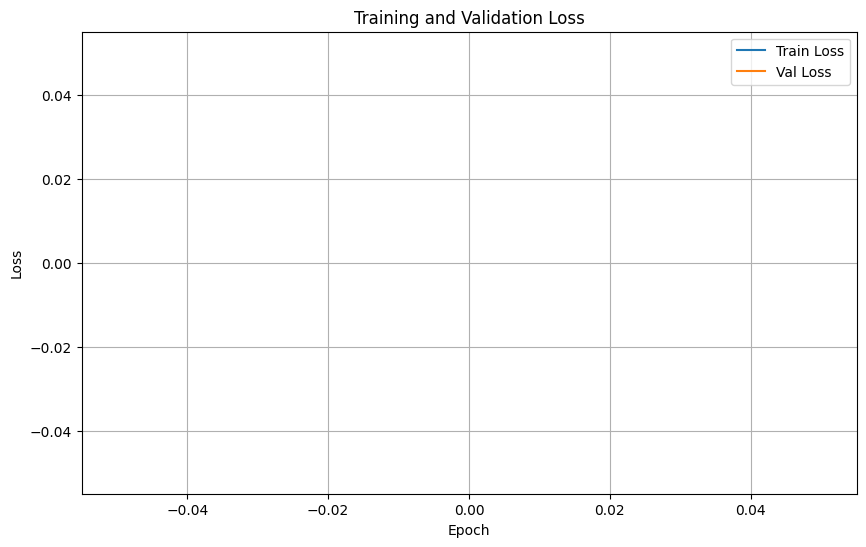

In [16]:
# Plot training and validation loss
import pandas as pd
log_df = pd.read_csv(log_path)
plt.figure(figsize=(10,6))
plt.plot(log_df['epoch'], log_df['train_loss'], label='Train Loss')
plt.plot(log_df['epoch'], log_df['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

## Visualize Model Prediction on a Test Chip

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.27865437..1.2222613].


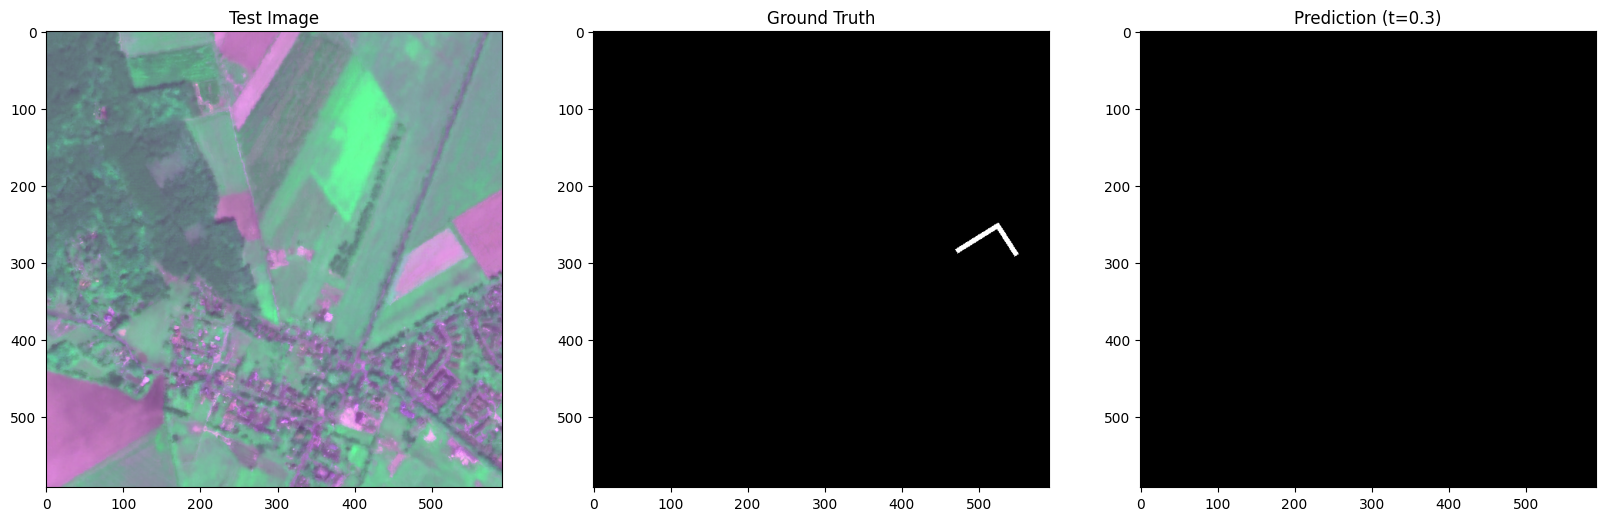

In [17]:
# Visualize prediction on a test chip
# Select a test image and label
#k = 1  # test batch (not used, for compatibility)
i = 12  # test example index
threshold = 0.3  # probability threshold

# Prepare test dataset and loader (single example)
test_dataset = HedgerowsDataset(test_images_paths, test_labels_paths, MONTHBANDS, NORM_COEF, CHIP_SIZE, augment=False)

test_example, test_label = test_dataset[i]
# test_example: (C, H, W), test_label: (1, H, W)

# Model expects batch dimension
best_model.eval()
with torch.no_grad():
    input_tensor = test_example.unsqueeze(0).to(device)  # (1, C, H, W)
    pred = best_model(input_tensor)
    pred = torch.sigmoid(pred).cpu().numpy()[0, 0]  # (H, W)

# Prepare for visualization
img_rgb = test_example.numpy().transpose(1, 2, 0)  # (H, W, C)
# If more than 3 bands, use bands 0,2,1 for RGB
if img_rgb.shape[2] >= 3:
    img_rgb = img_rgb[:, :, [0, 2, 1]]
label = test_label.numpy().squeeze()
pred_mask = (pred > threshold).astype(np.uint8)

fig, ax = plt.subplots(1, 3, figsize=(20, 10))
ax[0].imshow(img_rgb)
ax[1].imshow(label, cmap=plt.cm.gray)
ax[2].imshow(pred_mask, cmap=plt.cm.gray)
ax[0].set_title('Test Image')
ax[1].set_title('Ground Truth')
ax[2].set_title(f'Prediction (t={threshold})')
plt.show()

In [21]:
from sklearn.metrics import classification_report
import numpy as np
import tifffile
import os

pred_dir = '/mnt/data1/muro/s2dr3/predictions/nrg_pytorch_2022'

all_preds = []
all_labels = []

for idx in range(len(test_labels_paths)):
    img_name = os.path.basename(test_labels_paths[idx])
    pred_path = os.path.join(pred_dir, img_name)
    label_path = test_labels_paths[idx]
    if not os.path.exists(pred_path):
        print(f"Prediction missing for {img_name}, skipping.")
        continue
    pred_mask = tifffile.imread(pred_path)
    label = tifffile.imread(label_path)
    if label.ndim == 3:
        label = label.squeeze()
    # Pad label to CHIP_SIZE if needed
    lh, lw = label.shape
    if lh < CHIP_SIZE or lw < CHIP_SIZE:
        pad_h = max(0, CHIP_SIZE - lh)
        pad_w = max(0, CHIP_SIZE - lw)
        label = np.pad(label, ((0, pad_h), (0, pad_w)), mode='constant', constant_values=0)
    label = label[:CHIP_SIZE, :CHIP_SIZE]
    if pred_mask.shape != label.shape:
        print(f"Shape mismatch for {img_name}: pred {pred_mask.shape}, label {label.shape}, skipping.")
        continue
    all_preds.append(pred_mask.flatten())
    all_labels.append(label.flatten())

all_preds = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)

print(f"Total predictions: {all_preds.shape}, Total labels: {all_labels.shape}")
print(classification_report(all_labels, all_preds, digits=4))

Prediction missing for 1094-1374_chip_8_5_vrt_clip.tif, skipping.
Prediction missing for 1097-1378_chip_3_1_vrt_clip.tif, skipping.
Prediction missing for 1105-1377_chip_1_6_vrt_clip.tif, skipping.
Prediction missing for 1096-1378_chip_0_6_vrt_clip.tif, skipping.
Prediction missing for 1098-1379_chip_5_3_vrt_clip.tif, skipping.
Prediction missing for 1103-1374_chip_2_2_vrt_clip.tif, skipping.
Prediction missing for 1101-1369_chip_3_8_vrt_clip.tif, skipping.
Prediction missing for 1096-1374_chip_0_5_vrt_clip.tif, skipping.
Prediction missing for 1097-1375_chip_1_7_vrt_clip.tif, skipping.
Prediction missing for 1103-1370_chip_7_6_vrt_clip.tif, skipping.
Prediction missing for 1097-1371_chip_8_2_vrt_clip.tif, skipping.
Prediction missing for 1102-1370_chip_3_8_vrt_clip.tif, skipping.
Prediction missing for 1101-1378_chip_6_4_vrt_clip.tif, skipping.
Prediction missing for 1101-1382_chip_6_8_vrt_clip.tif, skipping.
Prediction missing for 1103-1382_chip_3_1_vrt_clip.tif, skipping.
Prediction

ValueError: need at least one array to concatenate

This is a specific function to measure accuracy. It measures how close in space labels and predicions are, even if they do not overlap.

In [ ]:
from scipy.ndimage import distance_transform_edt
from scipy.ndimage import binary_erosion as nd_binary_erosion
import numpy as np

def calculate_assd(predicted_chips, target_chips):
    assd_scores = []
    for pred, lbl in zip(predicted_chips, target_chips):
        pred = (pred > 0).astype(np.uint8)
        lbl = (lbl > 0).astype(np.uint8)
        if pred.sum() == 0 or lbl.sum() == 0:
            assd_scores.append(np.nan)
            continue
        # Distance from pred boundary to lbl
        dt_lbl = distance_transform_edt(1 - lbl)
        surface_pred = np.logical_xor(pred, nd_binary_erosion(pred))
        dists_pred_to_lbl = dt_lbl[surface_pred]
        # Distance from lbl boundary to pred
        dt_pred = distance_transform_edt(1 - pred)
        surface_lbl = np.logical_xor(lbl, nd_binary_erosion(lbl))
        dists_lbl_to_pred = dt_pred[surface_lbl]
        assd = (dists_pred_to_lbl.mean() + dists_lbl_to_pred.mean()) / 2
        assd_scores.append(assd)
    valid_assd_scores = [score for score in assd_scores if not np.isnan(score)]
    return np.median(valid_assd_scores)



In [ ]:
assd = calculate_assd(all_preds.reshape(-1, CHIP_SIZE, CHIP_SIZE), all_labels.reshape(-1, CHIP_SIZE, CHIP_SIZE))

In [ ]:
assd

2.9398370216045198

The previous calculate_assd function was slow for large masks because it computes full pairwise distances between all foreground pixels using cdist. This is O(N*M) for each chip, where N and M are the number of foreground pixels in prediction and label.

A more efficient approach is to use distance transforms, which compute the distance from every background pixel to the nearest foreground pixel in a single pass. This reduces the complexity to O(H*W) per chip and is much faster for large or dense masks.

The units of ASSD (Average Symmetric Surface Distance) are in pixels. So, if you get assd = 2.9, it means that, on average, the predicted and ground truth mask boundaries are 2.9 pixels apart from each other. If you know the physical size of a pixel (e.g., meters per pixel), you can multiply the ASSD value by that size to convert it to real-world units.